In [1]:
import os
import glob
import cv2
import numpy as np
import matplotlib.pyplot as plt
print("Basic libraries loaded.")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
print("PyTorch loaded.")

Basic libraries loaded.
PyTorch loaded.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Evaluation running on: {device}")

def compute_batch_metrics(preds, targets, threshold=0.5, smooth=1e-6):
    probs = torch.sigmoid(preds)
    preds_bin = (probs > threshold).float()

    preds_flat = preds_bin.view(-1)
    targets_flat = targets.view(-1)

    intersection = (preds_flat * targets_flat).sum().item()
    total_pred = preds_flat.sum().item()
    total_target = targets_flat.sum().item()

    dice = (2.0 * intersection + smooth) / (total_pred + total_target + smooth)
    iou = (intersection + smooth) / (total_pred + total_target - intersection + smooth)
    precision = (intersection + smooth) / (total_pred + smooth)
    recall = (intersection + smooth) / (total_target + smooth)

    return dice, iou, precision, recall

print("Metrics functions ready.")

Evaluation running on: cpu
Metrics functions ready.


In [3]:
class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): 
        return self.net(x)

class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(3, 32)
        self.down1 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(32, 64))
        self.down2 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(64, 128))
        self.down3 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(128, 256))
        self.down4 = nn.Sequential(nn.MaxPool2d(2), DoubleConv(256, 512))

        self.up1 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv_up1 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv_up2 = DoubleConv(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv_up3 = DoubleConv(128, 64)
        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.conv_up4 = DoubleConv(64, 32)
        self.outc = nn.Conv2d(32, 1, 1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.conv_up1(torch.cat([self.up1(x5), x4], dim=1))
        x = self.conv_up2(torch.cat([self.up2(x), x3], dim=1))
        x = self.conv_up3(torch.cat([self.up3(x), x2], dim=1))
        x = self.conv_up4(torch.cat([self.up4(x), x1], dim=1))
        return self.outc(x)

# Load model weights
model_path = "models/unet.pth"
assert os.path.exists(model_path), f"Checkpoint not found at {model_path}. Make sure it is downloaded."

model = UNet().to(device)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()
print(f"Loaded weights from {model_path}")

Loaded weights from models/unet.pth


In [4]:
class NucleiSegmentationDataset(Dataset):
    def __init__(self, images_dir, masks_dir):
        self.image_paths = sorted(glob.glob(os.path.join(images_dir, "*.png")))
        self.mask_paths = sorted(glob.glob(os.path.join(masks_dir, "*.png")))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        img = np.transpose(img, (2, 0, 1))

        mask = cv2.imread(self.mask_paths[idx], cv2.IMREAD_GRAYSCALE).astype(np.float32)
        mask = (mask > 127).astype(np.float32)
        mask = np.expand_dims(mask, axis=0)

        return torch.tensor(img, dtype=torch.float32), torch.tensor(mask, dtype=torch.float32)

test_dataset = NucleiSegmentationDataset("dataset/processed/test/images", "dataset/processed/test/masks")
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

total_dice, total_iou, total_precision, total_recall = 0.0, 0.0, 0.0, 0.0

with torch.no_grad():
    for images, masks in test_loader:
        images, masks = images.to(device), masks.to(device)
        outputs = model(images)
        
        dice, iou, prec, rec = compute_batch_metrics(outputs, masks)
        total_dice += dice
        total_iou += iou
        total_precision += prec
        total_recall += rec

num_batches = len(test_loader)
avg_dice = total_dice / num_batches
avg_iou = total_iou / num_batches
avg_precision = total_precision / num_batches
avg_recall = total_recall / num_batches

print("=" * 45)
print("       TEST SET EVALUATION METRICS          ")
print("=" * 45)
print(f"  Mean Dice Coefficient (F1): {avg_dice:.4f}")
print(f"  Mean IoU (Jaccard Index)  : {avg_iou:.4f}")
print(f"  Mean Precision            : {avg_precision:.4f}")
print(f"  Mean Recall (Sensitivity) : {avg_recall:.4f}")
print("=" * 45)

       TEST SET EVALUATION METRICS          
  Mean Dice Coefficient (F1): 0.6950
  Mean IoU (Jaccard Index)  : 0.5363
  Mean Precision            : 0.7848
  Mean Recall (Sensitivity) : 0.6363


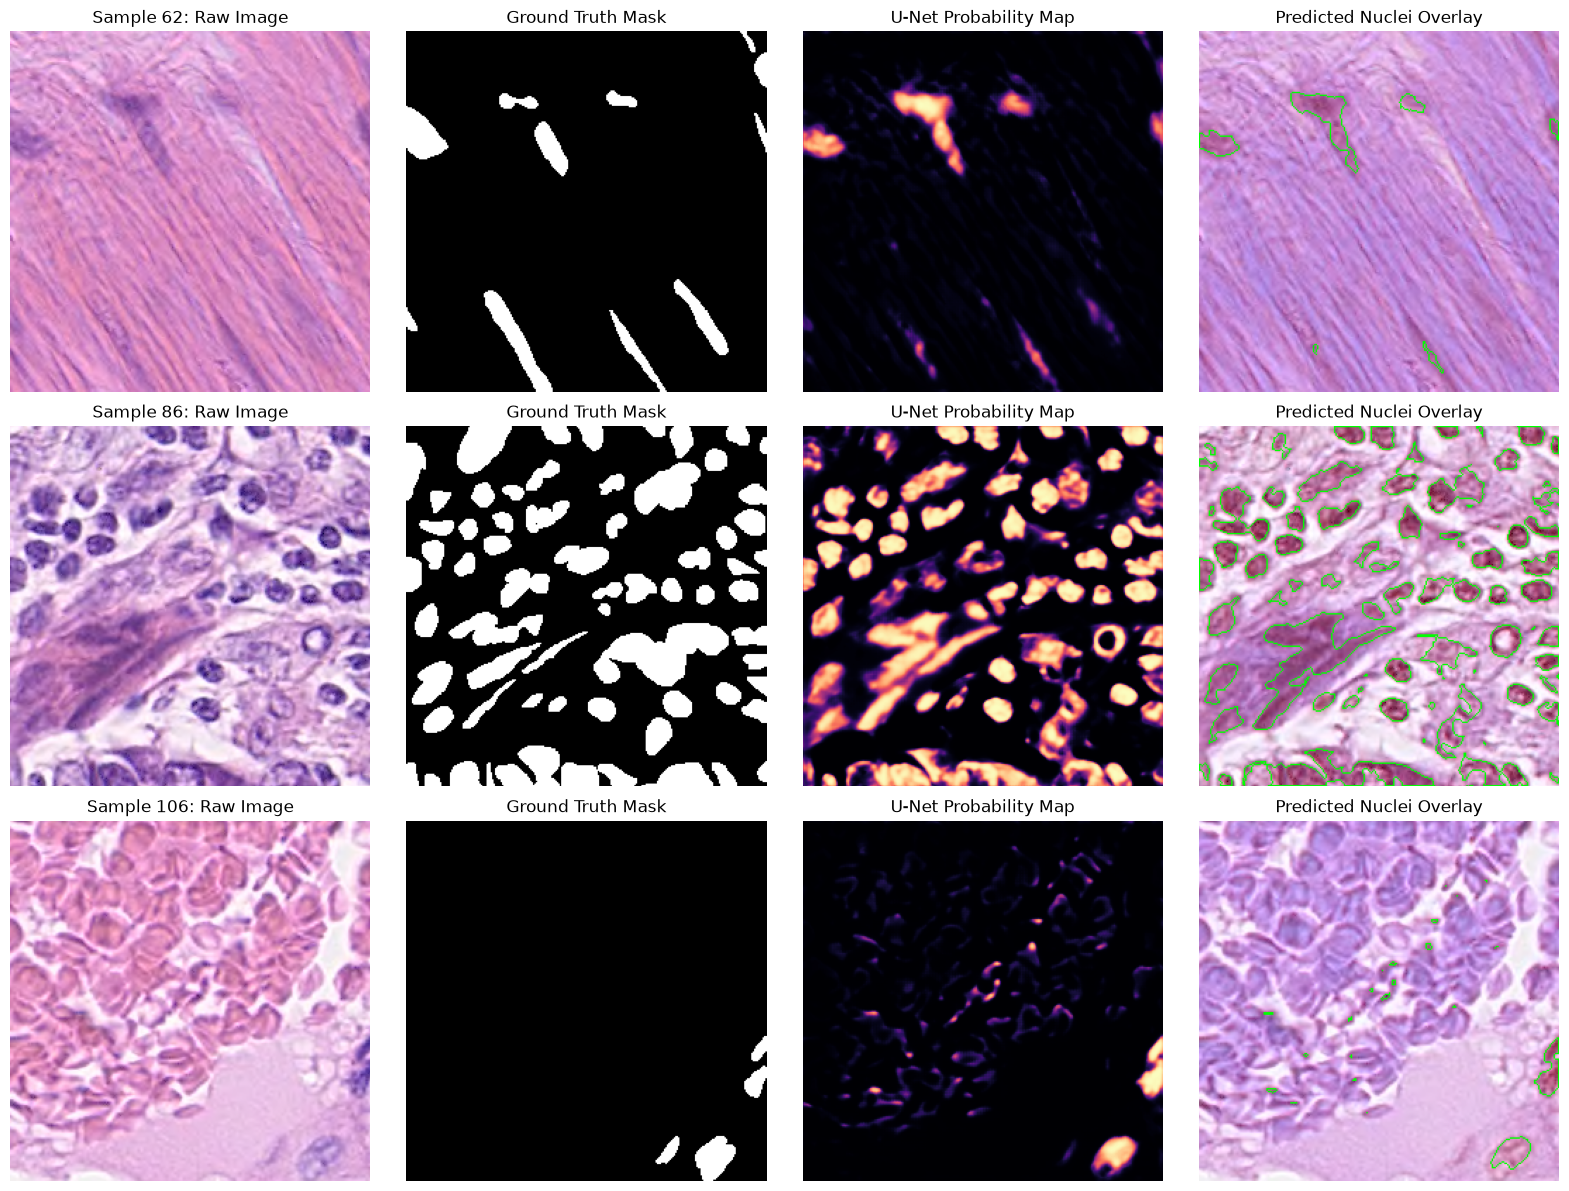

In [5]:
import random

indices = random.sample(range(len(test_dataset)), 3)

fig, axes = plt.subplots(len(indices), 4, figsize=(16, 4 * len(indices)))

with torch.no_grad():
    for row, idx in enumerate(indices):
        img_tensor, mask_tensor = test_dataset[idx]
        
        # Prepare inputs
        inp = img_tensor.unsqueeze(0).to(device)
        pred_logits = model(inp)
        pred_prob = torch.sigmoid(pred_logits).squeeze().cpu().numpy()
        pred_binary = (pred_prob > 0.5).astype(np.uint8)

        # Convert tensors to viewable numpy images
        img_vis = np.transpose(img_tensor.numpy(), (1, 2, 0))
        mask_vis = mask_tensor.squeeze().numpy()

        # Generate contour overlay on original image
        overlay = img_vis.copy()
        contours, _ = cv2.findContours(pred_binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        overlay_bgr = (overlay * 255).astype(np.uint8)
        cv2.drawContours(overlay_bgr, contours, -1, (0, 255, 0), 1)  # Green outlines

        # Plotting
        axes[row, 0].imshow(img_vis)
        axes[row, 0].set_title(f"Sample {idx}: Raw Image")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(mask_vis, cmap="gray")
        axes[row, 1].set_title("Ground Truth Mask")
        axes[row, 1].axis("off")

        axes[row, 2].imshow(pred_prob, cmap="magma")
        axes[row, 2].set_title("U-Net Probability Map")
        axes[row, 2].axis("off")

        axes[row, 3].imshow(cv2.cvtColor(overlay_bgr, cv2.COLOR_BGR2RGB))
        axes[row, 3].set_title("Predicted Nuclei Overlay")
        axes[row, 3].axis("off")

plt.tight_layout()
plt.show()

In [8]:
from scipy import ndimage
from skimage.feature import peak_local_max
from skimage.segmentation import watershed

def separate_and_extract_nuclei(raw_img, binary_mask, min_distance=7, min_area=30):
    """
    Applies distance transform and watershed algorithm to separate
    touching nuclei and extracts bounding boxes for classification.
    """
    # 1. Distance transform: calculates distance from each nucleus pixel to nearest background
    dist_map = cv2.distanceTransform((binary_mask * 255).astype(np.uint8), cv2.DIST_L2, 5)
    
    # 2. Find local peaks (nuclei centers)
    coordinates = peak_local_max(dist_map, min_distance=min_distance, labels=binary_mask)
    
    # 3. Create watershed markers
    markers = np.zeros(dist_map.shape, dtype=np.int32)
    for idx, (r, c) in enumerate(coordinates, start=1):
        markers[r, c] = idx
        
    markers = ndimage.label(markers)[0]
    
    # 4. Watershed to assign boundaries
    labels = watershed(-dist_map, markers, mask=binary_mask)
    
    # 5. Extract bounding boxes and individual cropped nuclei
    extracted_crops = []
    unique_labels = np.unique(labels)
    
    h, w, _ = raw_img.shape
    for label_id in unique_labels:
        if label_id == 0:  # Skip background
            continue
            
        nucleus_area = np.sum(labels == label_id)
        if nucleus_area < min_area:  # Filter out tiny noise artifacts
            continue
            
        # Get coordinates
        coords = np.where(labels == label_id)
        y_min, y_max = np.min(coords[0]), np.max(coords[0])
        x_min, x_max = np.min(coords[1]), np.max(coords[1])
        
        # Add a 4px padding around each cropped nucleus
        y_pad_min, y_pad_max = max(0, y_min - 4), min(h, y_max + 4)
        x_pad_min, x_pad_max = max(0, x_min - 4), min(w, x_max + 4)
        
        crop = raw_img[y_pad_min:y_pad_max, x_pad_min:x_pad_max]
        extracted_crops.append({
            "crop": crop,
            "bbox": (x_min, y_min, x_max, y_max),
            "area": nucleus_area
        })
        
    return labels, extracted_crops

# Run watershed on a test sample
sample_idx = 0
img_tensor, mask_tensor = test_dataset[sample_idx]

with torch.no_grad():
    inp = img_tensor.unsqueeze(0).to(device)
    pred_prob = torch.sigmoid(model(inp)).squeeze().cpu().numpy()
    pred_binary = (pred_prob > 0.5).astype(np.uint8)

raw_img_vis = np.transpose(img_tensor.numpy(), (1, 2, 0))
separated_labels, crops = separate_and_extract_nuclei(raw_img_vis, pred_binary)

print(f"Sample {sample_idx}: Successfully detected and separated {len(crops)} individual nuclei!")

Sample 0: Successfully detected and separated 43 individual nuclei!


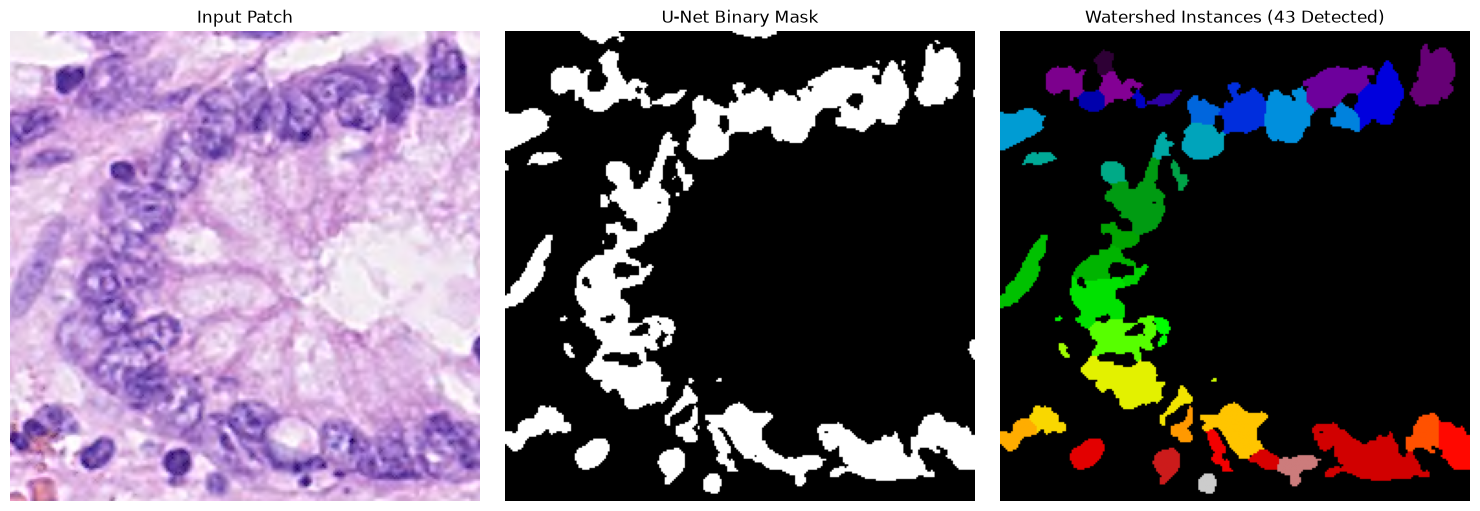

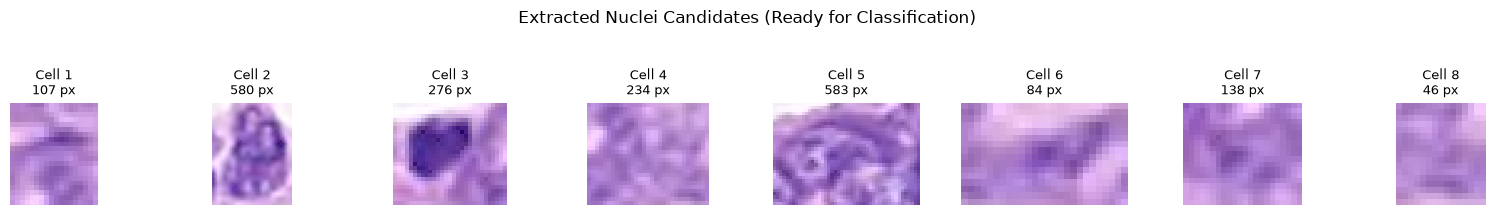

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Original patch
axes[0].imshow(raw_img_vis)
axes[0].set_title("Input Patch")
axes[0].axis("off")

# 2. Raw binary mask from U-Net
axes[1].imshow(pred_binary, cmap="gray")
axes[1].set_title("U-Net Binary Mask")
axes[1].axis("off")

# 3. Watershed labeled instances (each color = unique nucleus)
axes[2].imshow(separated_labels, cmap="nipy_spectral")
axes[2].set_title(f"Watershed Instances ({len(crops)} Detected)")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Show a gallery of extracted individual nuclei (first 8)
if len(crops) > 0:
    n_display = min(8, len(crops))
    fig, axes = plt.subplots(1, n_display, figsize=(2 * n_display, 2))
    
    for i in range(n_display):
        ax = axes[i] if n_display > 1 else axes
        ax.imshow(crops[i]["crop"])
        ax.set_title(f"Cell {i+1}\n{crops[i]['area']} px", fontsize=9)
        ax.axis("off")
        
    plt.suptitle("Extracted Nuclei Candidates (Ready for Classification)", y=1.05)
    plt.tight_layout()
    plt.show()